**U.S. Foreign Aid Annual Spend for Ethiopia**

Data was obtained from ForeignAssistance.gov (https://foreignassistance.gov), associated with the U.S. State Department.

In [1]:
import pandas as pd

df = pd.read_csv('results.csv')
df.shape

(3173, 51)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 51 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Country ID                              3173 non-null   int64 
 1   Country Code                            3173 non-null   object
 2   Country Name                            3173 non-null   object
 3   Region ID                               3173 non-null   int64 
 4   Region Name                             3173 non-null   object
 5   Income Group ID                         3173 non-null   int64 
 6   Income Group Name                       3173 non-null   object
 7   Income Group Acronym                    3173 non-null   object
 8   Managing Agency ID                      3173 non-null   int64 
 9   Managing Agency Acronym                 3173 non-null   object
 10  Managing Agency Name                    3173 non-null   object
 11  Mana

In [145]:
usaid_df = df[df['Managing Agency Acronym'] == 'USAID']
usaid_df.shape

(2726, 51)

In [146]:
# Limiting data by entries where USAID was the Managing Agency, and excluded influenza and "other" health threats. The data does include funding for general healtcare infrastructure, which isn't necessarily limited to the 3 diseases of interest: HIV/AIDS, malaria and TB.
usaid_df = df[(df['Managing Agency Acronym'] == 'USAID') & (df['US Sector Name'] != 'Other Public Health Threats') & (df['US Sector Name'] != 'Pandemic Influenza and Other Emerging Threats (PIOET)')]
usaid_df.shape

(2415, 51)

In [147]:
usaid_df.dtypes

Country ID                                 int64
Country Code                              object
Country Name                              object
Region ID                                  int64
Region Name                               object
Income Group ID                            int64
Income Group Name                         object
Income Group Acronym                      object
Managing Agency ID                         int64
Managing Agency Acronym                   object
Managing Agency Name                      object
Managing Sub-agency or Bureau ID           int64
Managing Sub-agency or Bureau Acronym     object
Managing Sub-agency or Bureau Name        object
Implementing Partner Category ID           int64
Implementing Partner Category Name        object
Implementing Partner Sub-category ID      object
Implementing Partner Sub-category Name     int64
Implementing Partner ID                    int64
Implementing Partner Name                 object
International Catego

In [148]:
df_columns = usaid_df[['Fiscal Year', 'Current Dollar Amount']]

In [149]:
#Converting Dollar Amount for Readability on Line Plot
df_columns['Current Dollar Amount'] = df_columns['Current Dollar Amount']/1000000

C:\Users\tlett\AppData\Local\Temp\ipykernel_18524\296915851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_columns['Current Dollar Amount'] = df_columns['Current Dollar Amount']/1000000


In [150]:
df_columns.describe()

,Fiscal Year,Current Dollar Amount
count,2415.000000,2415.000000
mean,2011.684886,0.910064
std,4.915660,2.386034
min,2001.000000,-5.017237
25%,2008.000000,0.002587
50%,2011.000000,0.114961
75%,2016.000000,0.771250
max,2021.000000,45.505316


In [151]:
df_group = df_columns.groupby('Fiscal Year', as_index=False).sum()
df_group

,Fiscal Year,Current Dollar Amount
0,2001,5.231653
1,2002,12.449080
2,2003,21.871108
3,2004,34.964624
4,2005,46.319730
5,2006,54.897661
6,2007,63.419838
7,2008,123.238527
8,2009,161.924491
9,2010,96.488232


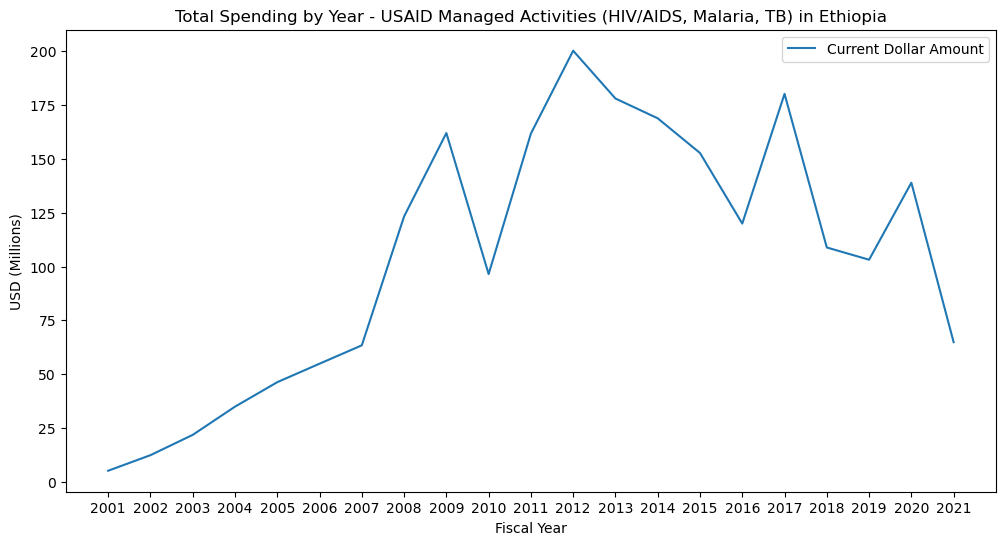

In [152]:
import matplotlib.pyplot as plt
df_group.plot.line(x='Fiscal Year', y='Current Dollar Amount', ylabel = 'USD (Millions)', title='Total Spending by Year - USAID Managed Activities (HIV/AIDS, Malaria, TB) in Ethiopia', xticks=df_group['Fiscal Year'], figsize = (12,6))
plt.show()


**Child Mortality Data**

Data was obtained from the UN Inter-agency Group for Child Mortality Estimation (https://childmortality.org/). Data was extracted for Ethiopia mortality, ages 5 and under, for 3 major diseases: HIV/AIDS, malaria and tuberculosis. 

In [155]:
df2 = pd.read_csv('UNICEF-CME_CAUSE_OF_DEATH-1.0-download.csv')
df2.shape

(66, 11)

In [156]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geographic area  66 non-null     object 
 1   Indicator        66 non-null     object 
 2   Cause of death   66 non-null     object 
 3   Sex              66 non-null     object 
 4   Age group        66 non-null     object 
 5   SERIES_NAME      66 non-null     object 
 6   Unit of measure  66 non-null     object 
 7   TIME_PERIOD      66 non-null     int64  
 8   OBS_VALUE        66 non-null     float64
 9   LOWER_BOUND      66 non-null     float64
 10  UPPER_BOUND      66 non-null     float64
dtypes: float64(3), int64(1), object(7)
memory usage: 5.8+ KB


In [157]:
unique_years = df2['TIME_PERIOD'].unique()
unique_years

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype=int64)

In [158]:
deaths_df = df2[(df2['TIME_PERIOD'] != 2000)]
deaths_df.shape

(63, 11)

In [159]:
deaths_df.describe()

,TIME_PERIOD,OBS_VALUE,LOWER_BOUND,UPPER_BOUND
count,63.000000,63.000000,63.000000,63.000000
mean,2011.000000,5374.597242,2661.476190,12702.857143
std,6.103938,4049.584037,2875.672409,7967.940890
min,2001.000000,1297.157492,0.000000,1560.000000
25%,2006.000000,1984.060139,0.000000,6830.000000
50%,2011.000000,3583.904114,1520.000000,12200.000000
75%,2016.000000,8278.339646,4330.000000,18650.000000
max,2021.000000,14118.000000,10400.000000,35200.000000


In [160]:
df_columns2 = deaths_df[['TIME_PERIOD', 'OBS_VALUE']]

In [161]:
# Combining causes of death for 3 diseases by year

df_group_deaths = df_columns2.groupby('TIME_PERIOD', as_index=False).sum()
df_group_deaths

,TIME_PERIOD,OBS_VALUE
0,2001,31317.713574
1,2002,28599.222593
2,2003,28376.216964
3,2004,27976.491974
4,2005,21581.094635
5,2006,19364.279816
6,2007,16800.012970
7,2008,14410.713135
8,2009,15955.665367
9,2010,16482.688721


In [162]:
df_group_deaths.describe()

,TIME_PERIOD,OBS_VALUE
count,21.000000,21.000000
mean,2011.000000,16123.791726
std,6.204837,8120.252282
min,2001.000000,4609.388344
25%,2006.000000,10185.509409
50%,2011.000000,15955.665367
75%,2016.000000,19364.279816
max,2021.000000,31317.713574


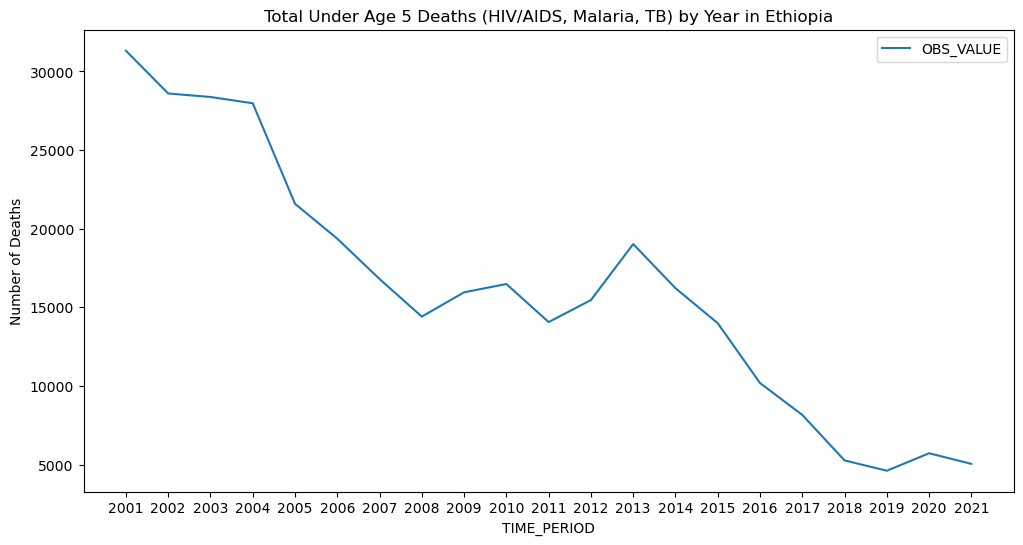

In [163]:
df_group_deaths.plot.line(x='TIME_PERIOD', y='OBS_VALUE', ylabel = 'Number of Deaths', title='Total Under Age 5 Deaths (HIV/AIDS, Malaria, TB) by Year in Ethiopia', xticks=df_group_deaths['TIME_PERIOD'],figsize = (12,6))
plt.show()

In [164]:
df_joined = df_group.join(df_group_deaths)

In [165]:
#Converting Dollar Amount back to Raw Value
df_joined['Current Dollar Amount'] = df_joined['Current Dollar Amount']*1000000
df_joined

,Fiscal Year,Current Dollar Amount,TIME_PERIOD,OBS_VALUE
0,2001,5231653.0,2001,31317.713574
1,2002,12449080.0,2002,28599.222593
2,2003,21871108.0,2003,28376.216964
3,2004,34964624.0,2004,27976.491974
4,2005,46319730.0,2005,21581.094635
5,2006,54897661.0,2006,19364.279816
6,2007,63419838.0,2007,16800.012970
7,2008,123238527.0,2008,14410.713135
8,2009,161924491.0,2009,15955.665367
9,2010,96488232.0,2010,16482.688721


In [166]:
df_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fiscal Year            21 non-null     int64  
 1   Current Dollar Amount  21 non-null     float64
 2   TIME_PERIOD            21 non-null     int64  
 3   OBS_VALUE              21 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 804.0 bytes


**Regression Plot Non-Normalized**

<Axes: xlabel='Current Dollar Amount', ylabel='OBS_VALUE'>

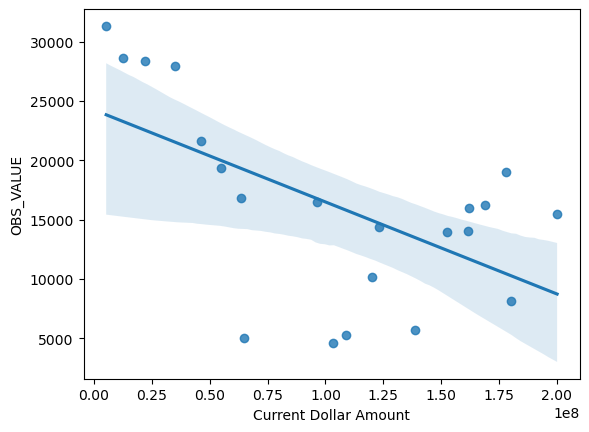

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

sns.regplot(x="Current Dollar Amount", y="OBS_VALUE", data=df_joined)

In [446]:
#Calculating Correlation
df_joined[['Current Dollar Amount', 'OBS_VALUE']].corr(method='pearson')

,Current Dollar Amount,OBS_VALUE
Current Dollar Amount,1.000000,-0.581505
OBS_VALUE,-0.581505,1.000000


In [170]:
#Commenting out Normalization
#df_joined['Current Dollar Amount'] = df_joined['Current Dollar Amount']/df_joined['Current Dollar Amount'].max()
df_joined.head()

,Fiscal Year,Current Dollar Amount,TIME_PERIOD,OBS_VALUE
0,2001,5231653.0,2001,31317.713574
1,2002,12449080.0,2002,28599.222593
2,2003,21871108.0,2003,28376.216964
3,2004,34964624.0,2004,27976.491974
4,2005,46319730.0,2005,21581.094635


**Importing Data for Net Migration**

Obtained from data.worldbank.org. Defined as the number of immigrants minus the number of emigrants, including both citizens and noncitizens.

In [198]:
df_migration = pd.read_csv('Net Migration (World Bank).csv')
df_migration.shape

(266, 68)

In [200]:
df_migration.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Net migration,SM.POP.NETM,-788.0,-566.0,-601.0,-650.0,-682.0,-727.0,...,333.0,373.0,405.0,434.0,431.0,420.0,0.0,503.0,152.0,147.0
1,Africa Eastern and Southern,AFE,Net migration,SM.POP.NETM,-102704.0,-38646.0,-56414.0,-42809.0,22280.0,7627.0,...,-414158.0,151528.0,-799850.0,340934.0,327087.0,100706.0,340127.0,187508.0,-220428.0,-989975.0
2,Afghanistan,AFG,Net migration,SM.POP.NETM,2606.0,6109.0,7016.0,6681.0,7079.0,10695.0,...,233913.0,-286314.0,-143049.0,-71491.0,-36753.0,9159.0,143634.0,-548784.0,-647402.0,-48958.0
3,Africa Western and Central,AFW,Net migration,SM.POP.NETM,-759.0,-36991.0,-31675.0,-32310.0,-40403.0,-11060.0,...,-181414.0,-247654.0,50874.0,-72945.0,-178068.0,-270812.0,-39974.0,-149585.0,-81809.0,327673.0
4,Angola,AGO,Net migration,SM.POP.NETM,-40935.0,-74774.0,-77265.0,-78700.0,-79977.0,-81111.0,...,84535.0,74171.0,91614.0,77731.0,61632.0,58984.0,7556.0,29094.0,-995.0,-995.0


In [220]:
df_mig = df_migration[(df_migration['Country Name'] == 'Ethiopia')]
df_mig.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
72,Ethiopia,ETH,Net migration,SM.POP.NETM,1696.0,6938.0,8960.0,9418.0,10749.0,16348.0,...,103122.0,62785.0,115823.0,71766.0,9302.0,-10807.0,38866.0,-1377.0,-11996.0,-11996.0


In [222]:
df_mig.set_index('Country Name', inplace=True)
df_mig.head()

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country Name,,,,,,,,,,,,,,,,,,,,,
Ethiopia,ETH,Net migration,SM.POP.NETM,1696.0,6938.0,8960.0,9418.0,10749.0,16348.0,9160.0,...,103122.0,62785.0,115823.0,71766.0,9302.0,-10807.0,38866.0,-1377.0,-11996.0,-11996.0


In [224]:
df_mig.index.name = None

In [232]:
df_mig = df_mig.transpose()
df_mig.head(15)

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Ethiopia,ETH,Net migration,SM.POP.NETM,1696.0,6938.0,8960.0,9418.0,10749.0,16348.0,9160.0,...,103122.0,62785.0,115823.0,71766.0,9302.0,-10807.0,38866.0,-1377.0,-11996.0,-11996.0


In [238]:
years2 = list(map(str, range(2001,2022)))
years2

['2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021']

In [242]:
df_migyears = df_mig[years2]
df_migyears = df_migyears.transpose()
df_migyears.head()

,Ethiopia
2001,-19063.0
2002,-12925.0
2003,-13744.0
2004,-25430.0
2005,-44421.0


In [244]:
df_migyears.reset_index(inplace=True)
df_migyears.head()

,index,Ethiopia
0,2001,-19063.0
1,2002,-12925.0
2,2003,-13744.0
3,2004,-25430.0
4,2005,-44421.0


In [250]:
df_migyears.columns = ['Year', 'Net_Migration']
df_migyears.tail()

,Year,Net_Migration
16,2017,71766.0
17,2018,9302.0
18,2019,-10807.0
19,2020,38866.0
20,2021,-1377.0


In [256]:
df_multi = df_joined.join(df_migyears)
df_multi.drop('TIME_PERIOD', axis=1, inplace=True)
df_multi.head()

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Year,Net_Migration
0,2001,5231653.0,31317.713574,2001,-19063.0
1,2002,12449080.0,28599.222593,2002,-12925.0
2,2003,21871108.0,28376.216964,2003,-13744.0
3,2004,34964624.0,27976.491974,2004,-25430.0
4,2005,46319730.0,21581.094635,2005,-44421.0


In [258]:
df_multi.drop('Year', axis=1, inplace=True)
df_multi.head()

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Net_Migration
0,2001,5231653.0,31317.713574,-19063.0
1,2002,12449080.0,28599.222593,-12925.0
2,2003,21871108.0,28376.216964,-13744.0
3,2004,34964624.0,27976.491974,-25430.0
4,2005,46319730.0,21581.094635,-44421.0


In [262]:
df_multi['Net_Migration'] = df_multi['Net_Migration'].astype("float")

In [264]:
df_multi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fiscal Year            21 non-null     int64  
 1   Current Dollar Amount  21 non-null     float64
 2   OBS_VALUE              21 non-null     float64
 3   Net_Migration          21 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 804.0 bytes


**Importing Unemployment Data**

Sourced from World Bank. Percentage of Total Workforce.

In [277]:
df_unemployment = pd.read_csv('Unempl_Ethiopia_WorldBank.csv')
df_unemployment.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2001,2002,2003,2004,2005,2006,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,7.676955,7.632330,7.586883,7.395648,7.218793,7.158958,...,7.181608,6.986733,6.947011,7.036357,7.194666,7.346331,7.360513,7.584419,8.191395,8.577385
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,7.953000,7.930000,7.880000,7.899000,7.885000,7.914000,...,7.856000,7.930000,7.915000,9.052000,10.133000,11.184000,11.196000,11.185000,11.710000,11.994000
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,4.479977,4.285854,4.180111,4.094738,4.100700,3.974095,...,3.982163,3.703853,3.881396,4.164467,4.157574,4.274196,4.323631,4.395271,4.852393,4.736732
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,16.700000,16.488000,16.498000,16.378000,16.360000,16.206000,...,16.562000,16.492000,16.406000,16.490000,16.575000,16.610000,16.594000,16.497000,16.690000,15.799000


In [288]:
df_unemp = df_unemployment[(df_unemployment['Country Name'] == 'Ethiopia')]
df_unemp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2001,2002,2003,2004,2005,2006,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
72,Ethiopia,ETH,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,3.176,3.06,2.995,2.767,2.497,2.351,...,2.255,2.251,2.359,2.443,2.554,2.662,2.802,2.917,3.994,3.935


In [290]:
df_unemp = df_unemp[years2]

In [296]:
df_unemp = df_unemp.transpose()
df_unemp.head()

,72
2001,3.176
2002,3.060
2003,2.995
2004,2.767
2005,2.497


In [298]:
df_unemp.reset_index(inplace=True)
df_unemp.head()

,index,72
0,2001,3.176
1,2002,3.060
2,2003,2.995
3,2004,2.767
4,2005,2.497


In [300]:
df_unemp.columns = ['Year', 'Unemployment Rate']
df_unemp.tail()

,Year,Unemployment Rate
16,2017,2.662
17,2018,2.802
18,2019,2.917
19,2020,3.994
20,2021,3.935


In [302]:
df_unemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               21 non-null     object 
 1   Unemployment Rate  21 non-null     float64
dtypes: float64(1), object(1)
memory usage: 468.0+ bytes


In [304]:
df_unemp.describe()

,Unemployment Rate
count,21.000000
mean,2.695524
std,0.510234
min,2.251000
25%,2.335000
50%,2.497000
75%,2.917000
max,3.994000


**Importing Stunting Data (Children Under 5)**

Sourced from https://data.who.int/

In [374]:
df_stunting = pd.read_csv('Stunting_Under5_WHO.csv')
df_stunting.shape

(5317, 14)

In [376]:
df_stunting.head()

,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_100_N,RATE_PER_100_NL,RATE_PER_100_NU
0,5F8A486NUTSTUNTINGPREV,NUTSTUNTINGPREV,5F8A486,NUTSTUNTINGPREV,1994,YEAR,013,REGION,PUBLISHED,Stunting in children (under 5),Central America,30.1,27.6,32.7
1,5F8A486NUTSTUNTINGPREV,NUTSTUNTINGPREV,5F8A486,NUTSTUNTINGPREV,2009,YEAR,788,COUNTRY,PUBLISHED,Stunting in children (under 5),Tunisia,9.6,8.8,10.6
2,5F8A486NUTSTUNTINGPREV,NUTSTUNTINGPREV,5F8A486,NUTSTUNTINGPREV,2020,YEAR,887,COUNTRY,PUBLISHED,Stunting in children (under 5),Yemen,36.7,30.6,43.1
3,5F8A486NUTSTUNTINGPREV,NUTSTUNTINGPREV,5F8A486,NUTSTUNTINGPREV,2015,YEAR,913,WORLDBANKINCOMEGROUP,PUBLISHED,Stunting in children (under 5),Low-and-middle-income countries,26.9,26.5,27.2
4,5F8A486NUTSTUNTINGPREV,NUTSTUNTINGPREV,5F8A486,NUTSTUNTINGPREV,1997,YEAR,954,WHOREGION,PUBLISHED,Stunting in children (under 5),Americas,15.3,14.8,15.8


In [378]:
df_stunt_columns = df_stunting[['DIM_TIME', 'GEO_NAME_SHORT', 'RATE_PER_100_N']]
df_stunt_columns.head()

,DIM_TIME,GEO_NAME_SHORT,RATE_PER_100_N
0,1994,Central America,30.1
1,2009,Tunisia,9.6
2,2020,Yemen,36.7
3,2015,Low-and-middle-income countries,26.9
4,1997,Americas,15.3


In [380]:
df_stunt = df_stunt_columns[(df_stunt_columns['DIM_TIME'] >= 2001) & (df_stunt_columns['DIM_TIME'] <= 2021) & (df_stunt_columns['GEO_NAME_SHORT'] == 'Ethiopia')]
df_stunt_sort = df_stunt.sort_values('DIM_TIME')
df_stunt_sort

,DIM_TIME,GEO_NAME_SHORT,RATE_PER_100_N
2758,2001,Ethiopia,55.8
3496,2002,Ethiopia,54.7
723,2003,Ethiopia,53.6
468,2004,Ethiopia,52.5
1447,2005,Ethiopia,51.3
2907,2006,Ethiopia,50.2
2981,2007,Ethiopia,48.9
5188,2008,Ethiopia,47.6
3558,2009,Ethiopia,46.1
4146,2010,Ethiopia,44.7


In [382]:
df_stunt_sort.columns = ['Year', 'Country', 'Stunting_Rate']
df_stunt_sort.columns

Index(['Year', 'Country', 'Stunting_Rate'], dtype='object')

In [384]:
df_stunt_sort.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 2758 to 1796
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           21 non-null     int64  
 1   Country        21 non-null     object 
 2   Stunting_Rate  21 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 672.0+ bytes


In [386]:
df_stunt_reset = df_stunt_sort.reset_index(drop=True)
df_stunt_reset

,Year,Country,Stunting_Rate
0,2001,Ethiopia,55.8
1,2002,Ethiopia,54.7
2,2003,Ethiopia,53.6
3,2004,Ethiopia,52.5
4,2005,Ethiopia,51.3
5,2006,Ethiopia,50.2
6,2007,Ethiopia,48.9
7,2008,Ethiopia,47.6
8,2009,Ethiopia,46.1
9,2010,Ethiopia,44.7


In [388]:
df_multi2 = df_multi.join(df_stunt_reset)
df_multi2

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Net_Migration,Year,Country,Stunting_Rate
0,2001,5231653.0,31317.713574,-19063.0,2001,Ethiopia,55.8
1,2002,12449080.0,28599.222593,-12925.0,2002,Ethiopia,54.7
2,2003,21871108.0,28376.216964,-13744.0,2003,Ethiopia,53.6
3,2004,34964624.0,27976.491974,-25430.0,2004,Ethiopia,52.5
4,2005,46319730.0,21581.094635,-44421.0,2005,Ethiopia,51.3
5,2006,54897661.0,19364.279816,-30512.0,2006,Ethiopia,50.2
6,2007,63419838.0,16800.012970,-381.0,2007,Ethiopia,48.9
7,2008,123238527.0,14410.713135,-20780.0,2008,Ethiopia,47.6
8,2009,161924491.0,15955.665367,16315.0,2009,Ethiopia,46.1
9,2010,96488232.0,16482.688721,80213.0,2010,Ethiopia,44.7


In [390]:
df_multi2.drop(['Year', 'Country'], axis=1, inplace=True)
df_multi2.head()

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Net_Migration,Stunting_Rate
0,2001,5231653.0,31317.713574,-19063.0,55.8
1,2002,12449080.0,28599.222593,-12925.0,54.7
2,2003,21871108.0,28376.216964,-13744.0,53.6
3,2004,34964624.0,27976.491974,-25430.0,52.5
4,2005,46319730.0,21581.094635,-44421.0,51.3


In [394]:
df_multi3 = df_multi2.join(df_unemp)
df_multi3.drop('Year', axis=1, inplace=True)
df_multi3.head()

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Net_Migration,Stunting_Rate,Unemployment Rate
0,2001,5231653.0,31317.713574,-19063.0,55.8,3.176
1,2002,12449080.0,28599.222593,-12925.0,54.7,3.060
2,2003,21871108.0,28376.216964,-13744.0,53.6,2.995
3,2004,34964624.0,27976.491974,-25430.0,52.5,2.767
4,2005,46319730.0,21581.094635,-44421.0,51.3,2.497


In [396]:
df_multi3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fiscal Year            21 non-null     int64  
 1   Current Dollar Amount  21 non-null     float64
 2   OBS_VALUE              21 non-null     float64
 3   Net_Migration          21 non-null     float64
 4   Stunting_Rate          21 non-null     float64
 5   Unemployment Rate      21 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 1.1 KB


In [398]:
df_multi3.describe()

,Fiscal Year,Current Dollar Amount,OBS_VALUE,Net_Migration,Stunting_Rate,Unemployment Rate
count,21.000000,2.100000e+01,21.000000,21.000000,21.000000,21.000000
mean,2011.000000,1.046573e+08,16123.791726,30286.523810,44.452381,2.695524
std,6.204837,6.092019e+07,8120.252282,55441.679922,6.710113,0.510234
min,2001.000000,5.231653e+06,4609.388344,-44421.000000,35.100000,2.251000
25%,2006.000000,5.489766e+07,10185.509409,-13744.000000,38.800000,2.335000
50%,2011.000000,1.088286e+08,15955.665367,9302.000000,43.300000,2.497000
75%,2016.000000,1.616883e+08,19364.279816,80213.000000,50.200000,2.917000
max,2021.000000,2.001319e+08,31317.713574,119517.000000,55.800000,3.994000


In [400]:
#Calculating Correlations
df_multi3[['Net_Migration', 'OBS_VALUE']].corr()

,Net_Migration,OBS_VALUE
Net_Migration,1.000000,-0.337114
OBS_VALUE,-0.337114,1.000000


In [402]:
df_multi3[['Stunting_Rate', 'OBS_VALUE']].corr()

,Stunting_Rate,OBS_VALUE
Stunting_Rate,1.000000,0.927123
OBS_VALUE,0.927123,1.000000


In [404]:
df_multi3[['Unemployment Rate', 'OBS_VALUE']].corr()

,Unemployment Rate,OBS_VALUE
Unemployment Rate,1.000000,-0.180976
OBS_VALUE,-0.180976,1.000000


**Fitting Multi Linear Regression**

In [406]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lm = LinearRegression()
Z = df_multi3[['Current Dollar Amount', 'Net_Migration', 'Stunting_Rate', 'Unemployment Rate']]
Y = df_multi3['OBS_VALUE']
lm.fit(Z,Y)
Yhat = lm.predict(Z)
mse = mean_squared_error(df_multi3['OBS_VALUE'], Yhat)
r2 = lm.score(Z,Y)
print(mse)
print(r2)

5628967.097724436
0.9103647230212379


*Distribution Graph*

C:\Users\tlett\AppData\Local\Temp\ipykernel_18524\1786698260.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax2 = sns.distplot(df_multi3['OBS_VALUE'], hist=False, color="r", label="Actual Value")
C:\Users\tlett\AppData\Local\Temp\ipykernel_18524\1786698260.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750b

<Axes: xlabel='OBS_VALUE', ylabel='Density'>

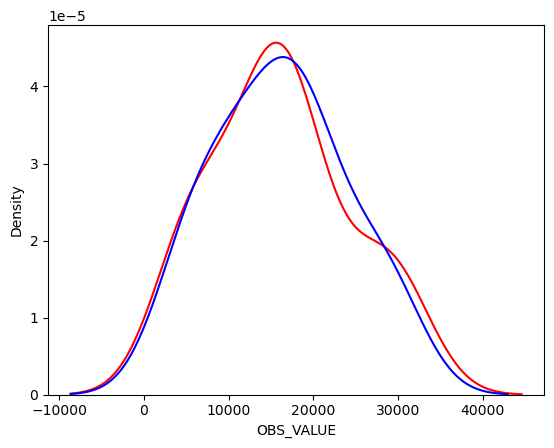

In [409]:
ax2 = sns.distplot(df_multi3['OBS_VALUE'], hist=False, color="r", label="Actual Value")
sns.distplot(Yhat, hist=False, color="b", label="Fitted Values", ax=ax2)

**Polynomial Pipeline (Multi-Variable)**

In [414]:
input = [('polynomial', PolynomialFeatures()), ('scale', StandardScaler()), ('Model', LinearRegression())]
pipe = Pipeline(input)
Z = Z.astype(float)
pipe.fit(Z,Y)
yhat = pipe.predict(Z)

In [416]:
mse_pipe = mean_squared_error(Y, yhat)
print("The MSE value is:", mse_pipe)
r2_pipe = r2_score(Y, yhat)
print("The R-squared value is:", r2_pipe)

The MSE value is: 622167.5323730385
The R-squared value is: 0.9900926478831267


**Conclusion:** Polynomial model has the highest R-squared value with .99